   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Dataset.zip:   0%|          | 0.00/795M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Success! Loaded 32580 drawings.


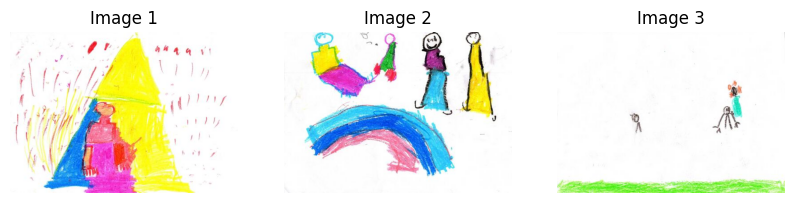

In [ ]:
!pip install datasets pillow matplotlib groq -q

from datasets import load_dataset
import matplotlib.pyplot as plt

print("Downloading the KIDO Children's Drawings dataset...")
dataset = load_dataset("serdarciftci/KIDO", split="train")

print(f"Success! Loaded {len(dataset)} drawings.")

# Show the first 3 images to verify
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    axes[i].imshow(dataset[i]['image'])
    axes[i].set_title(str(dataset[i].get('Emotion', f"Image {i+1}")))
    axes[i].axis('off')
plt.show()

In [ ]:
#  Configure Groq API
from groq import Groq
import getpass

print("Get your FREE API key from: https://console.groq.com/keys")
print("No credit card required!\n")

api_key = getpass.getpass("Paste your Groq API Key and press Enter: ")
client = Groq(api_key=api_key)


print("Testing connection...")
test = client.chat.completions.create(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    messages=[{"role": "user", "content": "Say OK"}],
    max_tokens=5
)
print(f"✅ Groq connected! Model ready: meta-llama/llama-4-scout-17b-16e-instruct")

Get your FREE API key from: https://console.groq.com/keys
No credit card required!

Paste your Groq API Key and press Enter: ··········
Testing connection...
✅ Groq connected! Model ready: meta-llama/llama-4-scout-17b-16e-instruct


In [ ]:
import time
import json
import os
import base64
from io import BytesIO

ALREADY_DONE = 0
NUM_SAMPLES = 2100     
SAVE_FILE = "graded_dataset.json"
DELAY_BETWEEN_REQUESTS = 3


if os.path.exists(SAVE_FILE):
    with open(SAVE_FILE, "r") as f:
        generated_dataset = json.load(f)
    ALREADY_DONE = len(generated_dataset)
    print(f"📂 Resumed from save — {ALREADY_DONE} images already graded.")
else:
    generated_dataset = []


rubric_prompt = """Act as an art teacher grading a student's hand-drawn paper sketch.
Evaluate this drawing on four criteria:
1. Clarity (Score 1-5): How easily can you identify what the drawing is?
2. Detail (Score 1-5): How much effort and detail was put into the drawing?
3. Creativity (Score 1-5): How imaginative or unique is the drawing?
4. Mood (1 word): What is the primary emotion or vibe of the drawing (e.g., Happy, Sad, Chaotic, Calm)?

Output your response STRICTLY in this JSON format, nothing else:
{"clarity": <score>, "detail": <score>, "creativity": <score>, "mood": "<word>", "explanation": "<1 sentence explanation>"}"""

def pil_to_base64(img):
    buffered = BytesIO()
    img.convert("RGB").save(buffered, format="JPEG", quality=85)
    return base64.standard_b64encode(buffered.getvalue()).decode("utf-8")

print(f"Starting from image {ALREADY_DONE+1}, grading up to {NUM_SAMPLES} total...")
print("-" * 50)

i = ALREADY_DONE
while i < NUM_SAMPLES:
    sample = dataset[i]
    image = sample['image']
    success = False

    while not success:  # keeps retrying same image until it succeeds
        try:
            img_b64 = pil_to_base64(image)

            response = client.chat.completions.create(
                model="meta-llama/llama-4-scout-17b-16e-instruct",
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": f"data:image/jpeg;base64,{img_b64}"
                                }
                            },
                            {
                                "type": "text",
                                "text": rubric_prompt
                            }
                        ]
                    }
                ],
                max_tokens=256,
                temperature=0.1
            )

            raw = response.choices[0].message.content.strip()
            raw = raw.removeprefix('```json').removesuffix('```').strip()
            grade_data = json.loads(raw)

          
            generated_dataset.append({
                "image_index": i,
                "clarity": grade_data.get("clarity"),
                "detail": grade_data.get("detail"),
                "creativity": grade_data.get("creativity"),
                "mood": grade_data.get("mood"),
                "explanation": grade_data.get("explanation")
            })

          
            with open(SAVE_FILE, "w") as f:
                json.dump(generated_dataset, f, indent=2)

          
            print(f"✅ Image {i+1}/{NUM_SAMPLES} | Clarity: {grade_data.get('clarity')} | Detail: {grade_data.get('detail')} | Creativity: {grade_data.get('creativity')} | Mood: {grade_data.get('mood')}", flush=True)

            success = True
            time.sleep(DELAY_BETWEEN_REQUESTS)

        except json.JSONDecodeError:
            print(f"⚠️ Image {i+1}: Bad JSON — retrying...", flush=True)
            time.sleep(3)
       

        except Exception as e:
            err_str = str(e)
            if "rate" in err_str.lower() or "429" in err_str:
                print(f"⏳ Rate limited on image {i+1} — waiting 60s then retrying...", flush=True)
                time.sleep(60)
            else:
                print(f"❌ Error on image {i+1}: {err_str[:120]} — skipping.", flush=True)
                success = True  
    i += 1

print(f"\n🎉 Pipeline complete! Graded {len(generated_dataset)}/{NUM_SAMPLES} images.")
print(f"💾 Saved to '{SAVE_FILE}'")

📂 Resumed from save — 1886 images already graded.
Starting from image 1887, grading up to 2100 total...
--------------------------------------------------
✅ Image 1887/2100 | Clarity: 4 | Detail: 3 | Creativity: 2 | Mood: Happy
✅ Image 1888/2100 | Clarity: 4 | Detail: 2 | Creativity: 3 | Mood: Happy
✅ Image 1889/2100 | Clarity: 4 | Detail: 3 | Creativity: 2 | Mood: Happy
✅ Image 1890/2100 | Clarity: 4 | Detail: 3 | Creativity: 4 | Mood: Happy
✅ Image 1891/2100 | Clarity: 5 | Detail: 2 | Creativity: 2 | Mood: Happy
✅ Image 1892/2100 | Clarity: 5 | Detail: 2 | Creativity: 3 | Mood: Sad
✅ Image 1893/2100 | Clarity: 4 | Detail: 2 | Creativity: 4 | Mood: Vibrant
✅ Image 1894/2100 | Clarity: 4 | Detail: 2 | Creativity: 3 | Mood: Playful
✅ Image 1895/2100 | Clarity: 4 | Detail: 2 | Creativity: 3 | Mood: Joyful
✅ Image 1896/2100 | Clarity: 3 | Detail: 2 | Creativity: 2 | Mood: Chaotic
✅ Image 1897/2100 | Clarity: 5 | Detail: 3 | Creativity: 4 | Mood: Happy
✅ Image 1898/2100 | Clarity: 4 | Deta

KeyboardInterrupt: 

In [ ]:
import json
import random
import matplotlib.pyplot as plt


SAVE_FILE = "graded_dataset.json"

try:
    with open(SAVE_FILE, "r") as f:
        generated_dataset = json.load(f)
    print(f"✅ Successfully loaded {len(generated_dataset)} graded records from {SAVE_FILE}\n")


    num_to_show = min(5, len(generated_dataset))
    sample_records = random.sample(generated_dataset, num_to_show)

    for record in sample_records:
        idx = record["image_index"]

      
        img = dataset[idx]['image']

      
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Dataset Index: {idx}")
        plt.show()

        
        print("📝 Groq API Generated Grade:")
      
        display_record = {k: v for k, v in record.items() if k != "image_index"}
        print(json.dumps(display_record, indent=2))
        print("\n" + "="*50 + "\n")

except FileNotFoundError:
    print(f"❌ Could not find '{SAVE_FILE}'. Make sure your grading loop saved the file or run the Google Drive restore cell!")

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("graded_dataset.json", "/content/drive/MyDrive/graded_dataset.json")
print("✅ Saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved to Google Drive!


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("/content/drive/MyDrive/graded_dataset.json", "graded_dataset.json")
print("✅ Restored! Ready to resume.")

Mounted at /content/drive
✅ Restored! Ready to resume.
